# Question 3

### Which product categories generate the highest average spending per transaction?

**Columns for analysis**
* `category`: represents product categoried such as Shoes, Technology, etc.
* `price`: represents spending per transaction. 

First, we are going to define a function called `plot_mean_spending_by_category`. The purpose of this function is to help us identify which product categories generate the highest average spending per transaction. To do this, the function will first group the dataset by the `category` column, which represents different types of products. For each category, it will calculate the mean (average) value of the `price` column, which tells us how much, on average, customers spend in each category per transaction. After calculating these averages, the function will sort the categories from highest to lowest average spending, making it easy to see which categories stand out.

The function will then create a bar chart to visually display these results. In this chart, each bar represents a product category, and the height of the bar shows the average spending for that category. This visualization makes it much easier to compare categories at a glance than looking at raw numbers in a table. By using this function, we expect to directly answer our main question: which product categories generate the highest average spending per transaction? The categories with the tallest bars in the chart will be the ones that contribute the most revenue per transaction, helping us focus on the most valuable segments in the dataset.

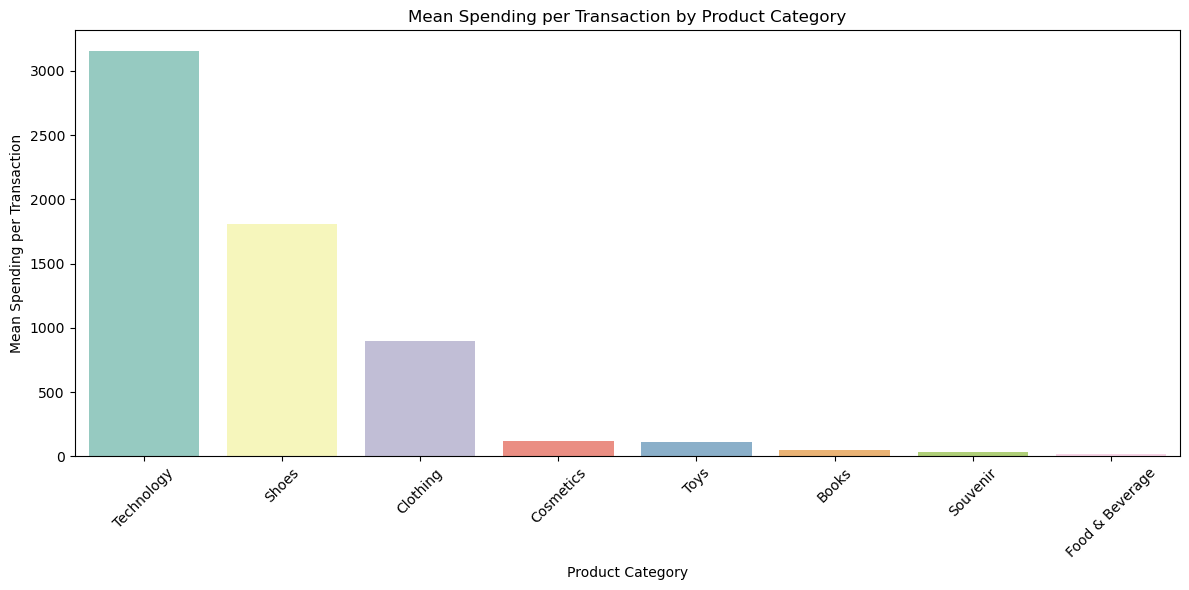

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('customer_shopping_data.csv')
mean_spend = df.groupby('category')['price'].mean().sort_values(ascending=False).reset_index()
mean_spend.columns = ['category', 'mean_spend']

def plot_mean_spending_by_category(df):
    plt.figure(figsize=(12,6))
    sns.barplot(data=mean_spend, x='category', y='mean_spend', hue='category', palette='Set3', legend=False)
    plt.ylabel('Mean Spending per Transaction')
    plt.xlabel('Product Category')
    plt.title('Mean Spending per Transaction by Product Category')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    return mean_spend

mean_spending = plot_mean_spending_by_category(df)

The bar chart above illustrates the average spending per transaction by product category. From the visualization, it is clear that the Technology category stands out as the top performer, recording the highest mean spending per transaction among all categories. Shoes and Clothing follow, but with noticeably lower averages than Technology.

On the other hand, categories such as Cosmetics, Toys, Books, Souvenir, and especially Food & Beverage display significantly lower average spending per transaction. This visual analysis answers our question directly: Technology products generate the highest average transaction value, followed by Shoes and Clothing.

By presenting each category with a different color, the chart makes these differences easy to distinguish at a glance. This insight is crucial for businesses or analysts looking to focus marketing efforts or strategize around categories that drive the most revenue per transaction.

Next, we are going to define a function called `plot_distribution_by_category`. The aim of this function is to help us understand how spending behavior varies within each product category, not just at the average level. While our bar chart showed which categories had higher average transaction amounts, it doesn’t reveal whether most transactions are close to that average or if spending is highly variable within a category.

In the `plot_distribution_by_category` function, we will visualize the distribution of spending amounts for each product category by using kernel density estimate (KDE) plots. For each category, we’ll display a smooth curve that shows how transaction amounts are spread; whether they cluster tightly around a single value, have a long tail of high-spending outliers, or are broadly distributed. By plotting all categories on the same axes, using different colors for each curve, we will make it easy to compare their shapes and identify differences in consumer behavior.

This visualization is important for answering questions like: "Do some categories attract a few very high spenders, or is spending consistent across transactions?" With this function, we expect to see not only which categories are generally profitable on average, but also how much variation or spread exists in spending patterns, which can be key for strategic planning and understanding market segments.

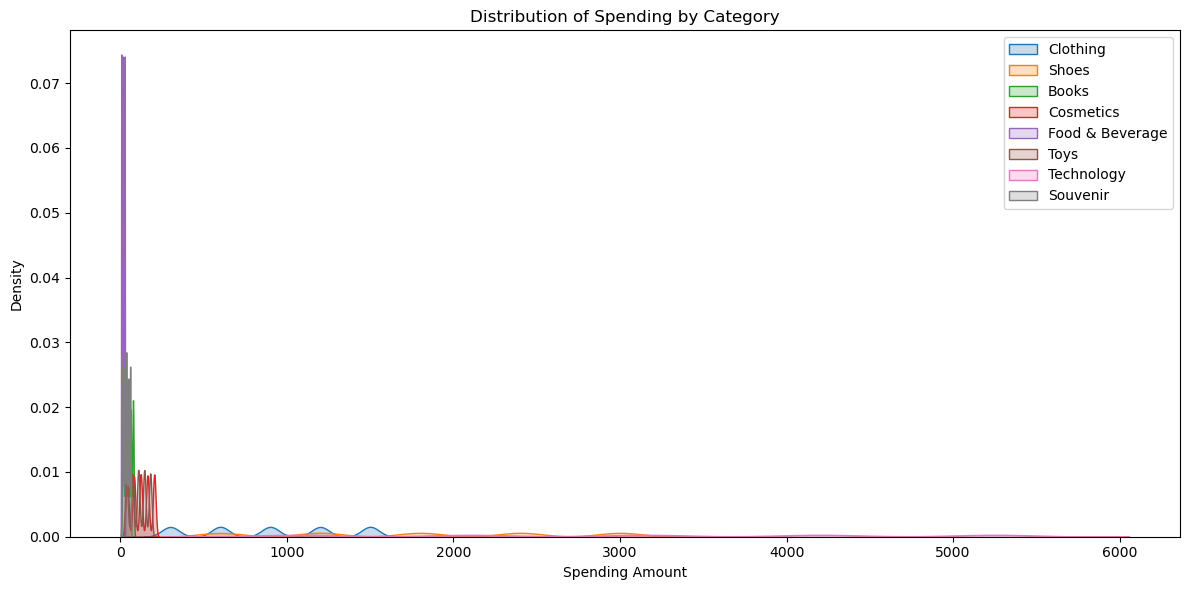

In [2]:
def plot_distribution_by_category(df):
    plt.figure(figsize=(12,6))
    for cat in df['category'].unique():
        sns.kdeplot(df[df['category']==cat]['price'], label=cat, fill=True)
    plt.xlabel('Spending Amount')
    plt.title('Distribution of Spending by Category')
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_distribution_by_category(df)

The distribution plot above reveals how transaction amounts are spread within each product category. Most categories, such as Food & Beverage, Books, Cosmetics, Toys, and Souvenir, show a high density of transactions at low spending amounts which indicate that the majority of purchases in these segments are for relatively small sums. In contrast, categories like Clothing, Shoes, and especially Technology have a much broader distribution, with spending amounts extending much further along the x-axis. This means that while most purchases in lower-spending categories are small, shopping for Technology, Shoes, or Clothing can involve far higher transaction values.

From this visualization, we can see that the Technology category not only leads in terms of highest average spending (as the bar chart showed earlier) but also exhibits a wider range of spending, including some exceptionally large transactions. This spread explains why Technology maintains such a high average: it captures both everyday sales and high-value purchases. Meanwhile, the other categories tend to cluster tightly around lower transaction amounts, with little high-end spending. This helps us understand not just which categories are the top revenue drivers overall, but also how customer behavior varies by product type, highlighting the role of big-ticket purchases in certain categories.

In [3]:
print('Top Categories by Mean Spend:')
print(mean_spending.head(5))

Top Categories by Mean Spend:
     category   mean_spend
0  Technology  3156.935548
1       Shoes  1807.388568
2    Clothing   901.084021
3   Cosmetics   122.448626
4        Toys   107.733185


Combining the insights from both the bar chart, the distribution plot, and the summary data, we can clearly see that Technology is the product category with the highest average spending per transaction, around 3,157 per transaction. Shoes and Clothing are the next highest, but with averages that are significantly lower than Technology, at about 1,807 and 901, respectively. In contrast, other categories such as Cosmetics and Toys have much lower average spending per transaction, well under 150.

The distribution plots add further detail: they show that in Technology, Shoes, and Clothing, not only are averages higher, but transaction amounts are also more variable, with many high-value purchases, while categories like Cosmetics, Toys, and others are clustered tightly around low spending values.

**Key takeaway**: If the goal is to maximize average transaction revenue, focusing on Technology, Shoes, and Clothing will have the greatest impact. These categories invite both higher and more variable spending, likely reflecting bigger-ticket items compared to the smaller, more common purchases in Cosmetics, Toys, and similar categories. This information is valuable for marketing strategies, inventory prioritization, and understanding shopper behavior across categories.